Multi-fidelity Modeling and Experimental Design (Active Learning)

In [1]:
# General imports
import numpy as np
np.random.seed(20)
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import colors as mcolors
colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)
import sys
import os
sys.path.append('../utilities')
import simulation_utils as sim
import plotting_utils as plotting
import drawing_utils_v8 as draw_mfsm
import multi_fidelity_surrogate_model_v8 as mfsm
from emukit.multi_fidelity.convert_lists_to_array import convert_x_list_to_array, convert_xy_lists_to_arrays

In [2]:
version = 'v1.8'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')
if not os.path.exists(f'in/Ge77_rates_new_samples_{version}.csv'):
   fout = open(f'in/Ge77_rates_new_samples_{version}.csv')
   fout.write("#\n ,Sample,Mode,Radius[cm],Thickness[cm],NPanels,Theta[deg],Length[cm],Ge-77[nevents],Ge-77_CNP,Ge-77_CNP_err")
   fout.close()
   

# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius [cm]','Thickness [cm]','NPanels', 'Angle [deg]', 'Length [cm]']

y_err_label_cnp = 'Ge-77_CNP_err'
y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,2,4,0,1]
xhigh=[250,15,360,90,150]

# Assign costs
low_fidelity_cost = 1.
high_fidelity_cost = 2000.
n_fidelities = 2
# Set a fixed point in space for drawings
x_fixed = [160, 2, 40, 45, 20]
# number of sigma for error band drawing on prediction
factor=1.

# Get LF noise from file
#with open(f'in/{file_in}') as f:
#    first_line = f.readline()
#LF_noise=np.round(float(first_line.split(' +')[0].split('= ')[1]),3)
LF_noise = 0.028
# Get HF and LF data samples from file

data=pd.read_csv(f'in/{file_in}')
#data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],y_label_cnp,y_err_label_cnp,y_label_sim]]


In [3]:

#data.plot(kind='scatter', x=x_labels[2], y=x_labels[3], alpha=0.4, s=data[x_labels[4]]*2, label='Ge-77',
#figsize=(12, 8), c=y_label, cmap=plt.get_cmap('jet'), colorbar=True)
#plt.legend()
#plt.show()

In [4]:

x_train_l, x_train_h, y_train_l, y_train_h = ([],[],[],[])
row_h=data.index[data['Mode'] == 1].tolist()
row_l=data.index[data['Mode'] == 0].tolist()

x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
y_train_hf_sim = data.loc[data['Mode']==1.][y_label_sim].to_numpy().tolist()

x_train_lf_sim = data.loc[data['Mode']==0.][x_labels].to_numpy().tolist()
y_train_lf_sim = data.loc[data['Mode']==0.][ y_label_sim].to_numpy().tolist()


x_train_lf_sim, x_train_hf_sim, y_train_lf_sim, y_train_hf_sim = (np.atleast_2d(x_train_lf_sim), np.atleast_2d(x_train_hf_sim), np.atleast_2d(y_train_lf_sim).T, np.atleast_2d(y_train_hf_sim).T)
X_train, Y_train = convert_xy_lists_to_arrays([x_train_lf_sim,x_train_hf_sim], [y_train_lf_sim,y_train_hf_sim])


In [5]:

mf_model = mfsm.linear_multi_fidelity_model(X_train, Y_train ,[LF_noise,0.0], n_fidelities)

 /Users/aschuetz/.local/modules/miniconda/miniconda3/envs/legend/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:divide by zero encountered in log


Optimization restart 1/100, f = -259.04737862510297
Warning - optimization restart 2/100 failed
Warning - optimization restart 3/100 failed
Warning - optimization restart 4/100 failed
Warning - optimization restart 5/100 failed
Warning - optimization restart 6/100 failed
Warning - optimization restart 7/100 failed
Warning - optimization restart 8/100 failed
Warning - optimization restart 9/100 failed
Warning - optimization restart 10/100 failed
Warning - optimization restart 11/100 failed
Warning - optimization restart 12/100 failed
Warning - optimization restart 13/100 failed
Warning - optimization restart 14/100 failed
Warning - optimization restart 15/100 failed
Warning - optimization restart 16/100 failed
Warning - optimization restart 17/100 failed
Warning - optimization restart 18/100 failed
Warning - optimization restart 19/100 failed
Warning - optimization restart 20/100 failed
Warning - optimization restart 21/100 failed
Warning - optimization restart 22/100 failed
Warning - o

 /Users/aschuetz/.local/modules/miniconda/miniconda3/envs/legend/lib/python3.10/site-packages/GPy/core/__init__.py:80: FutureWarning:In the future `np.bool` will be defined as the corresponding NumPy scalar.


In [6]:
%%capture
leg_label = []
ncol=1
nrow=int(np.ceil(len(x_labels)/ncol))
fig1,ax1  = plt.subplots(2,3, figsize=(15, 5),layout="constrained")
fig2,ax2  = plt.subplots(nrow,ncol, figsize=(5, 12),layout="constrained")

In [7]:
add_new_sample=True
sample=0
total_samples=20

Sample # 0
Sample # 1
Adding LF sample at [183.8, 5.1, 219.0, 49.0, 19.8] with rGe77[nuc/(kg*yr)] of [0.1392]
Adding HF sample at [183.8, 5.1, 219.0, 49.0, 19.8] with rGe77[nuc/(kg*yr)] of [0.1447]
Sample # 2
Adding LF sample at [184.2, 5.1, 218.0, 48.9, 17.8] with rGe77[nuc/(kg*yr)] of [0.1596]
Adding HF sample at [184.2, 5.1, 218.0, 48.9, 17.8] with rGe77[nuc/(kg*yr)] of [0.1671]
Sample # 3
Adding LF sample at [202.4, 2.7, 29.0, 10.4, 78.7] with rGe77[nuc/(kg*yr)] of [0.1856]
Adding HF sample at [202.4, 2.7, 29.0, 10.4, 78.7] with rGe77[nuc/(kg*yr)] of [0.1939]
Sample # 4
Adding LF sample at [208.4, 4.3, 18.0, 3.0, 50.6] with rGe77[nuc/(kg*yr)] of [0.1516]
Adding HF sample at [208.4, 4.3, 18.0, 3.0, 50.6] with rGe77[nuc/(kg*yr)] of [0.1897]
Sample # 5
Adding LF sample at [225.2, 9.6, 7.0, 0.0, 3.5] with rGe77[nuc/(kg*yr)] of [0.168]
Adding HF sample at [225.2, 9.6, 7.0, 0.0, 3.5] with rGe77[nuc/(kg*yr)] of [0.1778]
Sample # 6
Adding LF sample at [201.4, 2.6, 317.0, 52.1, 16.6] with r

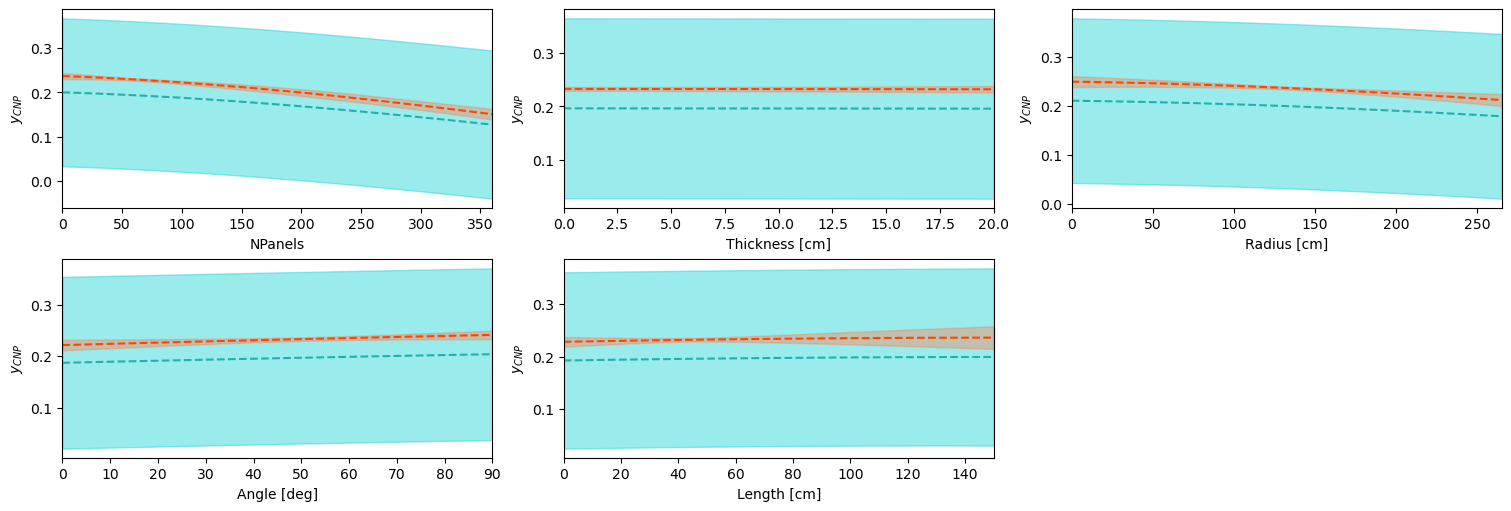

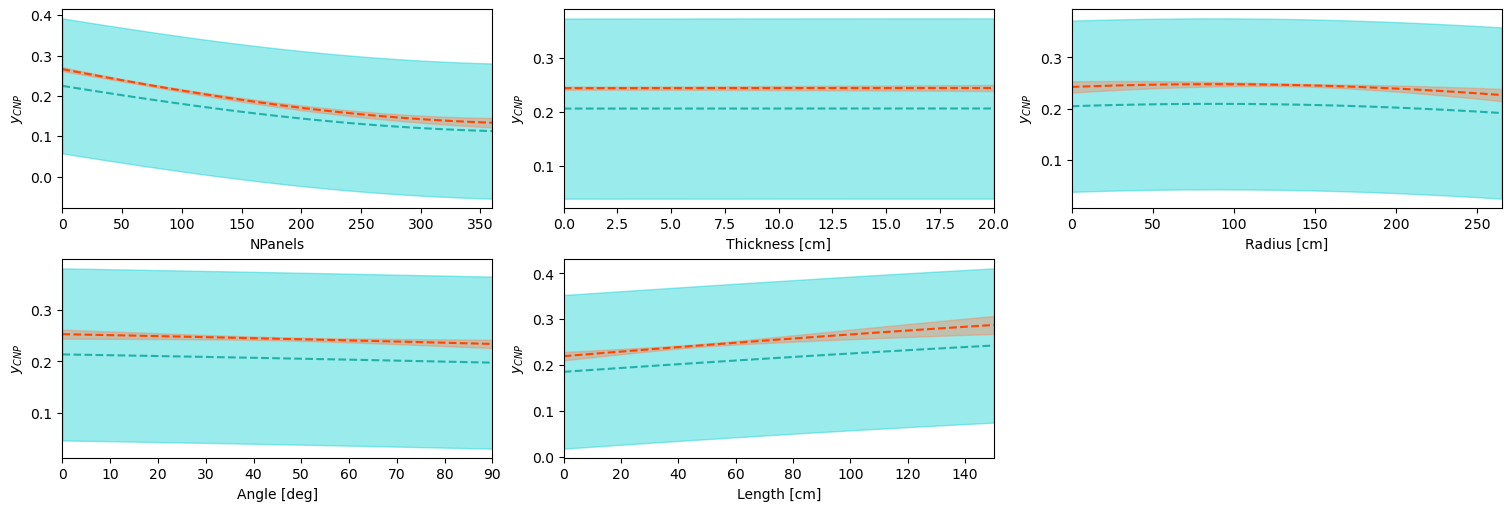

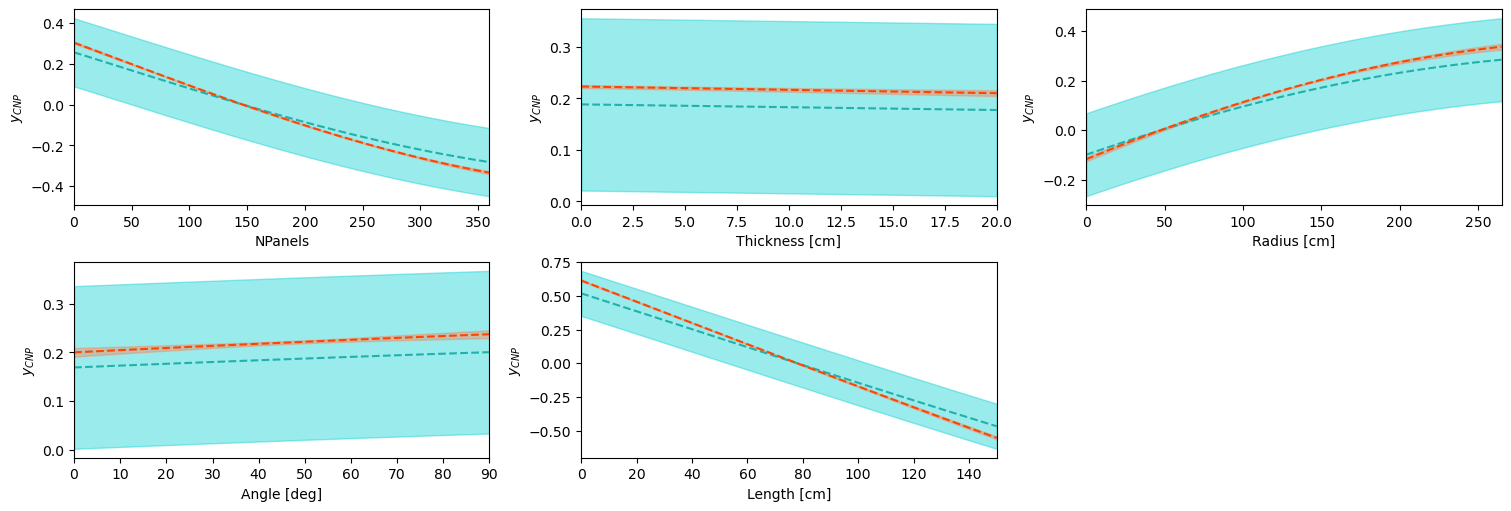

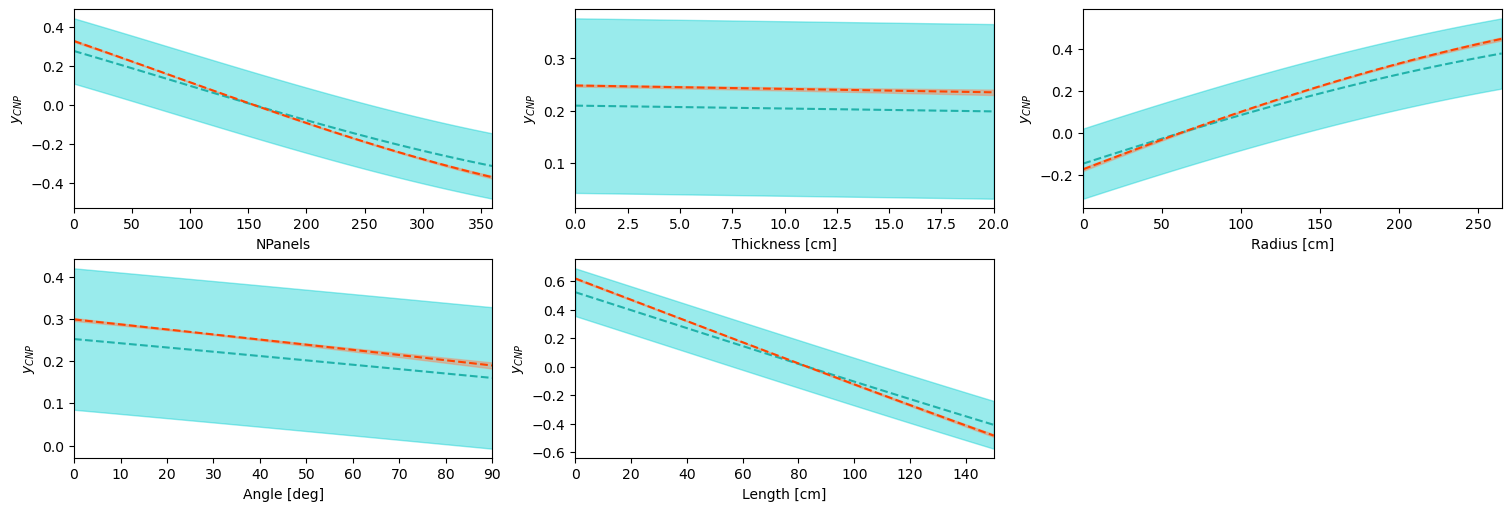

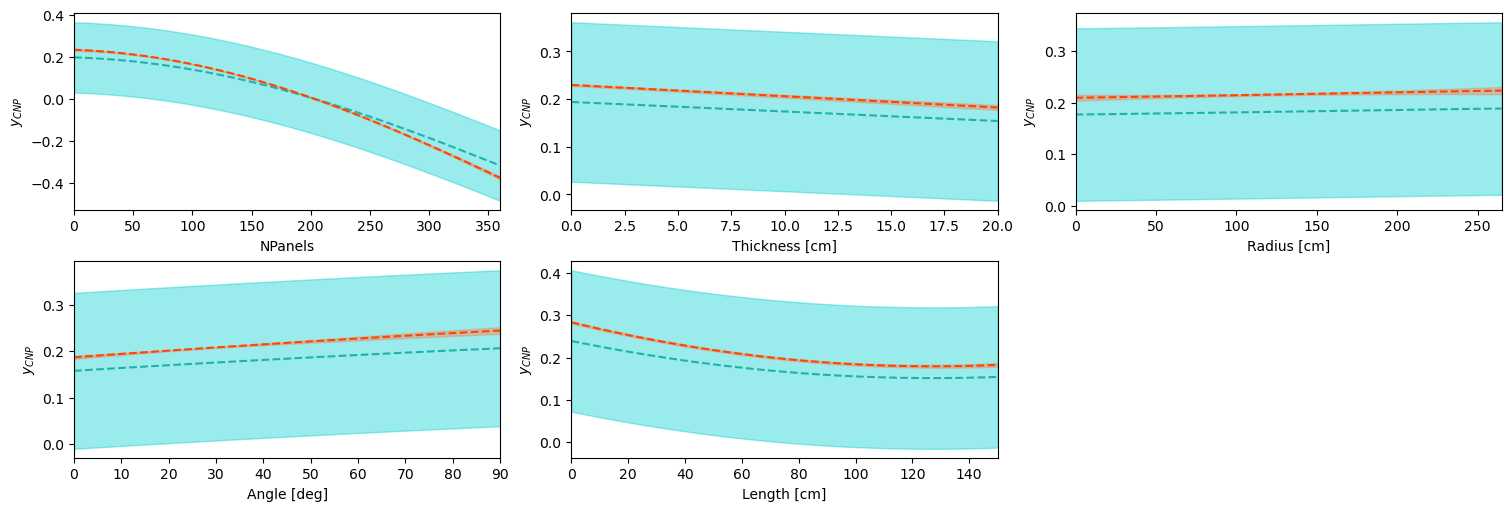

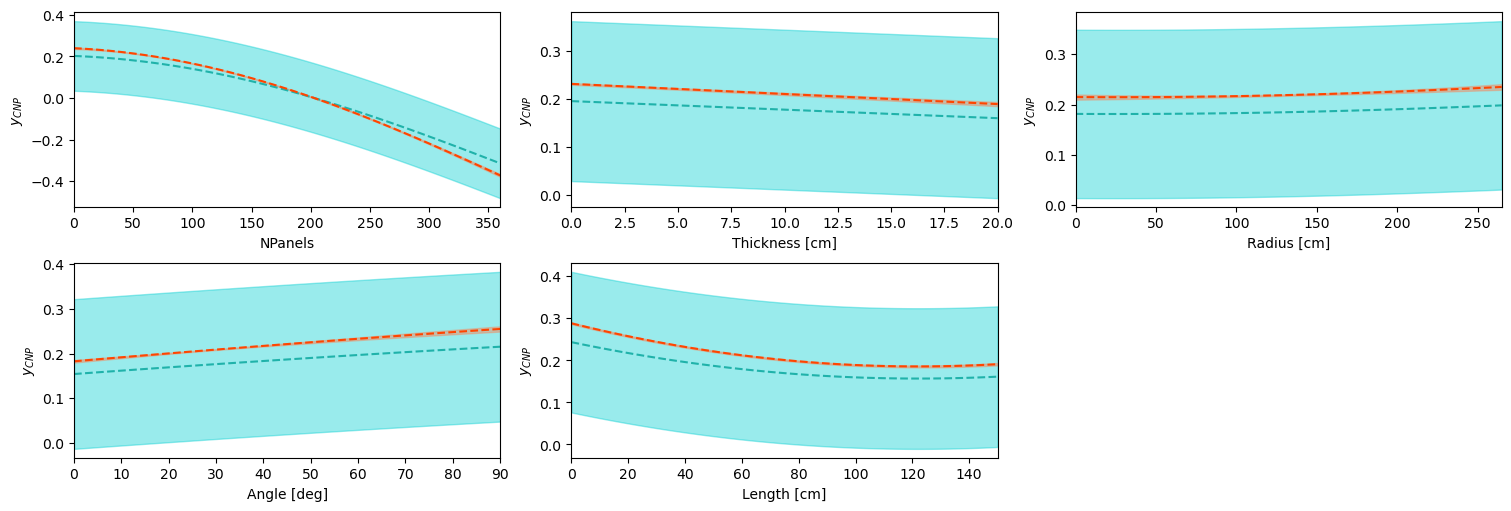

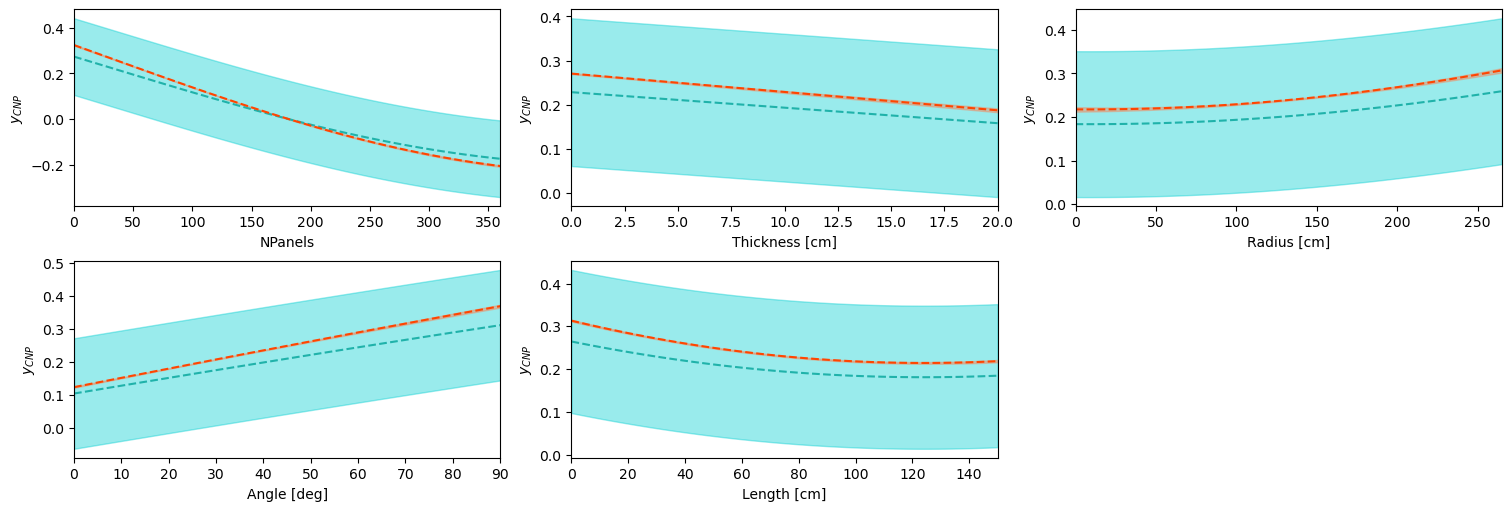

In [8]:

while ( sample < total_samples and sample <= max(mfsm.get_num_new_samples(version)[0],mfsm.get_num_new_samples(version)[1])+1 ):
    print('Sample #', sample)
    # add new data point to training data and update model with new training data
    x_new_data=np.array([])
    y_new_data_h=np.array([])
    if sample > 0:
        x_train_lf_sim, y_train_lf_sim, x_train_hf_sim, y_train_hf_sim, mf_model = mfsm.add_samples(x_train_lf_sim, y_train_lf_sim, x_train_hf_sim, y_train_hf_sim, mf_model, x_labels, y_label_sim ,sample-1, version)

    # run the model drawing
    draw_mfsm.draw_model(mf_model, xmin, xmax, x_labels_out, n_fidelities, version)#
    #fig1 = draw_mfsm.draw_model_updated(fig1, mf_model, xmin, xmax, x_labels_out, factor, version, x_fixed=x_fixed)
    #fig1.show()
    #fig1.savefig("update.png")

    # find the next data point
    #x_next_sample, us_acquisition = mfsm.max_acquisition_integrated_variance_reduction(mf_model, xlow, xhigh, x_labels)
    #print(f'next suggested point to simulated is at: {x_next_sample}')
    #sim.print_geant4_macro(x_next_sample[0],f"n{sample}",mode="LF",version=version)
    #sim.print_geant4_macro(x_next_sample[0],f"n{sample}",mode="HF",version=version)
    #plotting.draw_moderator_config(x_next_sample[0][0],x_next_sample[0][1],x_next_sample[0][2],x_next_sample[0][3],x_next_sample[0][4])
    #fig2 = draw_mfsm.draw_acquisition_func(fig2, us_acquisition, xlow, xhigh, x_labels_out, np.array(x_next_sample), version, x_fixed=x_fixed)
    #xi =x_next_sample[0,:-1]

    sample+=1




In [9]:
#draw_mfsm.draw_model_acquisition_func(fig1,fig2,x_labels,version)

In [10]:

def model_validation(mf_model, file_in, x_labels, y_label, version):
        data=pd.read_csv(file_in)
        #data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],y_label]]
        nfidelities = 2
        x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
        y_train_hf_sim = data.loc[data['Mode']==1.][y_label].to_numpy().tolist()
        x_train_hf_sim, y_train_hf_sim = (np.atleast_2d(x_train_hf_sim), np.atleast_2d(y_train_hf_sim).T)

        counter_1sigma = 0
        counter_2sigma = 0
        counter_3sigma = 0

        mfsm_model_mean = np.empty(shape=[0, 0])
        mfsm_model_std = np.empty(shape=[0, 0])
        hf_data=[]
        x=[]
        for i in range(len(x_train_hf_sim)):

                SPLIT = 1
                x_plot = (np.atleast_2d(x_train_hf_sim[i]))

                x_tmp =[]
                for f in range(nfidelities):
                        x_tmp.append(x_plot)
                X_plot = convert_x_list_to_array(x_tmp)

                hhf_mean_mf_model, hhf_var_mf_model = mf_model.predict(X_plot[SPLIT*(nfidelities-1):SPLIT*(nfidelities)])
                hhf_std_mf_model = np.sqrt(hhf_var_mf_model)

                hf_data.append(y_train_hf_sim[i])
                x.append(i)
                mfsm_model_mean=np.append(mfsm_model_mean,hhf_mean_mf_model[0,0])
                mfsm_model_std=np.append(mfsm_model_std,hhf_std_mf_model[0,0])
                if (y_train_hf_sim[i] < hhf_mean_mf_model+hhf_std_mf_model) and (y_train_hf_sim[i] > hhf_mean_mf_model-hhf_std_mf_model):
                        counter_1sigma += 1
                if (y_train_hf_sim[i] < hhf_mean_mf_model+2*hhf_std_mf_model) and (y_train_hf_sim[i] > hhf_mean_mf_model-2*hhf_std_mf_model):
                        counter_2sigma += 1
                if (y_train_hf_sim[i] < hhf_mean_mf_model+3*hhf_std_mf_model) and (y_train_hf_sim[i] > hhf_mean_mf_model-3*hhf_std_mf_model):
                        counter_3sigma += 1

        print("1 sigma: ", counter_1sigma/len(hf_data)*100.," %" )
        print("2 sigma: ", counter_2sigma/len(hf_data)*100.," %" )
        print("3 sigma: ", counter_3sigma/len(hf_data)*100.," %" )

        fig = plt.subplots(figsize=(12, 2.5))
        #plt.bar(x=np.arange(len(mfsm_model_mean)), height=mfsm_model_mean, color="lightgray", label='RESuM')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-3*mfsm_model_std, y2=mfsm_model_mean+3*mfsm_model_std, color="coral",alpha=0.2, label=r'$\pm 3\sigma$')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-2*mfsm_model_std, y2=mfsm_model_mean+2*mfsm_model_std, color="yellow",alpha=0.2, label=r'$\pm 2\sigma$')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-mfsm_model_std, y2=mfsm_model_mean+mfsm_model_std, color="green",alpha=0.2, label=r'MFGP model $\pm 1\sigma$')
        plt.xlabel('HF Simulation Trial Number')
        plt.ylim(0.,1.4)
        plt.ylabel(r'$y_{raw}$')
        plt.plot(x[:],hf_data[:],'.',color="black", label="HF Validation Data")
        handles, labels = plt.gca().get_legend_handles_labels()
        order = [3,2,1,0]
        plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=9, bbox_to_anchor=(0.665,1.),ncol=5)
        plt.savefig(f'out/{version}/model-validation_{version}.png')
        return fig

1 sigma:  1.0  %
2 sigma:  4.0  %
3 sigma:  5.0  %


(0.0, 0.5)

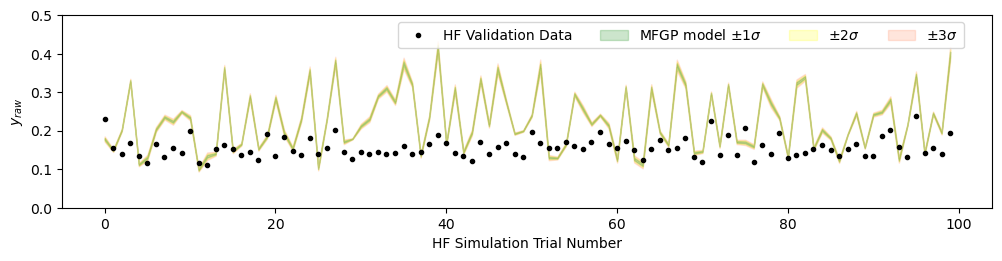

In [11]:
fig = model_validation(mf_model,"in/hf_validation_data_v1.2.csv",x_labels, y_label_sim, version)

plt.ylim(0.,0.5)




In [12]:
kernels = [3,4]
n_fidelities=3
for f in range(n_fidelities-2):
        kernels.append(3)
        kernels.append(4)
print(kernels)

[3, 4, 3, 4]


In [13]:
pdf=PdfPages(f'out/{version}/model-min_{version}.pdf')
x_fmin = [150,10,360,0,3]
f_min = 1.
for i in range(10):
    x_fmin_tmp, f_min_tmp = mfsm.get_min_constrained(mf_model, xlow, xhigh, x_labels)
    plotting.draw_moderator_configuration(x_fmin_tmp)
    #pdf.savefig()
    print(f"minimum found at {x_fmin_tmp} with f = {f_min_tmp} and a reduction of {mfsm.evaluate_model([0.,0.,0.,0.,0.],mf_model,2)/f_min_tmp}")
    #draw_mfsm.draw_model(mf_model, xmin, xmax, x_labels_out, factor, version,x_fixed=x_fmin_tmp)#
    #pdf.savefig()
    if f_min_tmp <= f_min:
        x_fmin = x_fmin_tmp
        f_min = f_min_tmp
    #if i % 10 ==0:
    #    print(i,f"*** minimum found at {x_fmin} with f = {f_min} and a reduction of {y_train_hf_sim[0][0]/f_min}")
    #    plotting.draw_moderator_configuration(x_fmin)
    #    pdf.savefig()
    itmp=201+i
    sim.print_geant4_macro(x_fmin_tmp,f"{itmp}",mode="LF",version=f"{version}")

pdf.close()

print(f"minimum found at {x_fmin} with f = {f_min} and a reduction of {mfsm.evaluate_model([0.,0.,0.,0.,0.], mf_model,2)/f_min}")
print("high fidelity", mfsm.evaluate_model(x_fmin, mf_model,2), mfsm.evaluate_model([x_fmin[0],plotting.get_outer_radius(x_fmin)-plotting.get_inner_radius(x_fmin),360,0.,4.],mf_model,2))
print("medium fidelity", mfsm.evaluate_model(x_fmin, mf_model,1), mfsm.evaluate_model([x_fmin[0],plotting.get_outer_radius(x_fmin)-plotting.get_inner_radius(x_fmin),360,0.,10.],mf_model,1))

plotting.draw_moderator_configuration(x_fmin)

#draw_mfsm.draw_model(mf_model, xmin, xmax, x_labels_out, factor, version,x_fixed=x_fmin)#
print(mfsm.check_inequalities(x_fmin),(x_fmin[2]*x_fmin[1]*x_fmin[4])/(np.pi*(plotting.get_outer_radius(x_fmin)**2-plotting.get_inner_radius(x_fmin)**2)))
itmp = 1000+sample
sim.print_geant4_macro(x_fmin,f"{itmp}",mode="LF",version=f"{version}")
sim.print_geant4_macro(x_fmin,f"{itmp}",mode="HF",version=f"{version}")

IndexError: list index out of range